# Data Visualization Using `plotnine` and the grammar of graphics



## Cars Data

The Palmer Penguins dataset had a variety of column types with which to explore some nice visualizations. The `mtcars` dataset is another popular dataset for doing some simple data work, but does not contain the same types of variables.

Run the following code to load the `mtcars` dataset and explore the observations and variables contained within. To learn more about this dataset check out [this site](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html)

---
Title: "Title"
format:
    html:
        embed-resources: true

In [1]:
import statsmodels.api as sm
import pandas as pd

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)

In [2]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


The statement "the `mtcars` dataset does not contain the same types of variables as the penguins dataset" is a little true and a little false. There are no variables that contain text values, BUT there are variables that it makes sense to consider categorical variables. In most situations, it makes sense to treat the values of categorical variables as text values instead of numeric values.

Some of these variables, like the `cyl` variable, have numeric values that actually make sense as numbers (i.e. the number of cylinders in the engine). However, it doesn't make the most sense to "do math" with this type of variable (e.g. take averages and such) because there are so few different value this can take on AND they're an explicit choice made by the car manufacturer. So, it makes more sense to treat the `cyl` variable as a categorical variable despite it having numeric values.

You will need to keep these kinds of nuances about data in mind as you work with an increasing variety and richness of data, and do more complex things with them

Use the `astype()` method to convert the categorical variables of the `mtcars` (df) dataset to have text values in the code chunk below. We've done one for you!

In [13]:
categorical_columns = ["am", "cyl", "vs", "gear", "carb"]
df[categorical_columns] = df[categorical_columns].astype(str)
df.dtypes

NameError: name 'df' is not defined

If you print out your new dataset, is it clear that the variables have been converted to text values? If so, how can you tell?

Let's see how `plotnine` treats these variables.


1\. Create side-by-side boxplots of the `mpg` variable by the different values of the `am` variable.

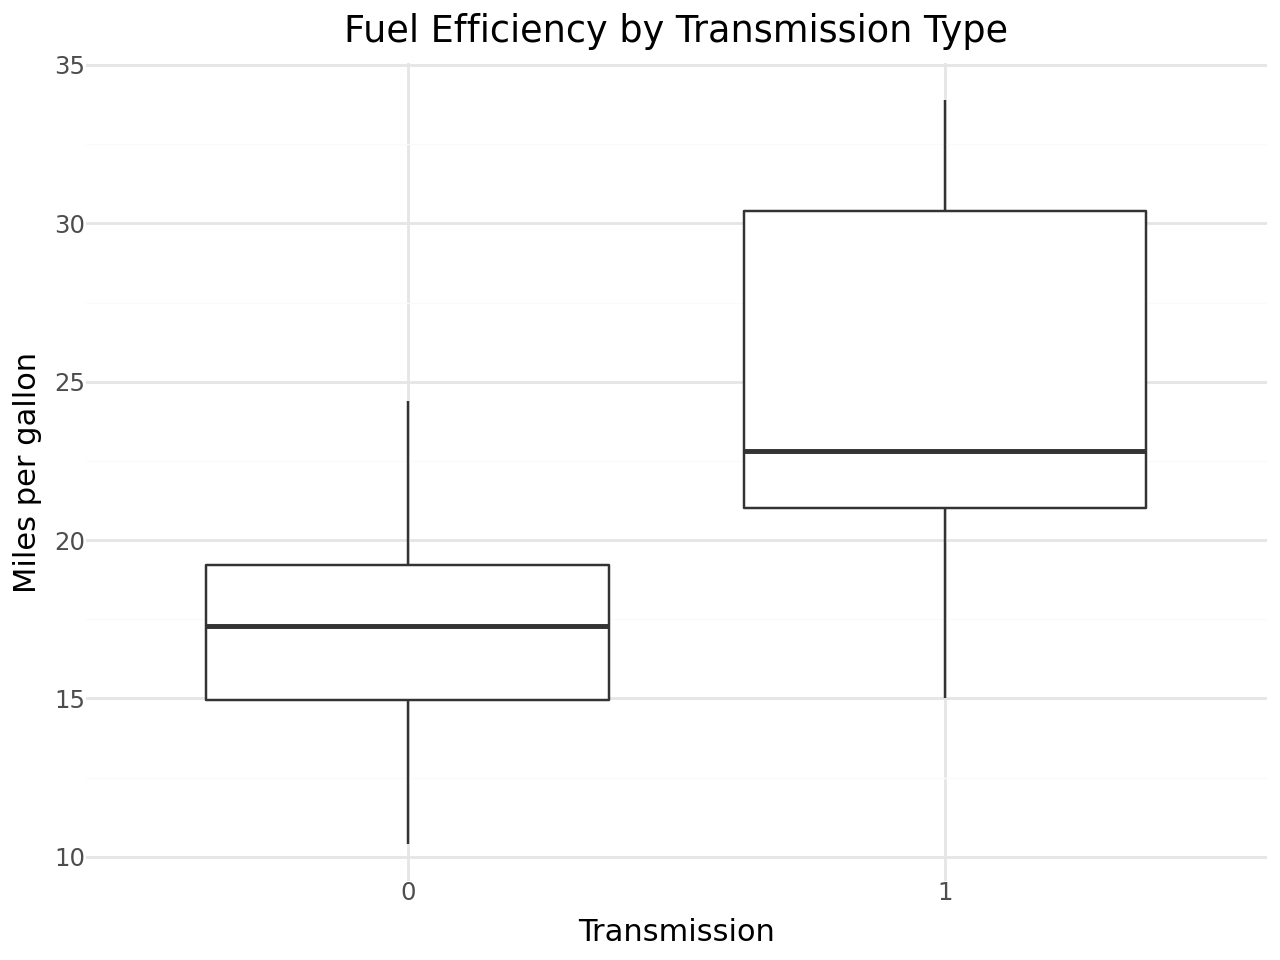

In [4]:
# Enter your code here
from plotnine import ggplot, aes, geom_boxplot, labs, theme_minimal
(
    ggplot(df, aes(x="am", y="mpg"))
    + geom_boxplot()
    + labs(
        x="Transmission",
        y="Miles per gallon",
        title="Fuel Efficiency by Transmission Type"
    )
    + theme_minimal())

2\. What happens if you convert the `am` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

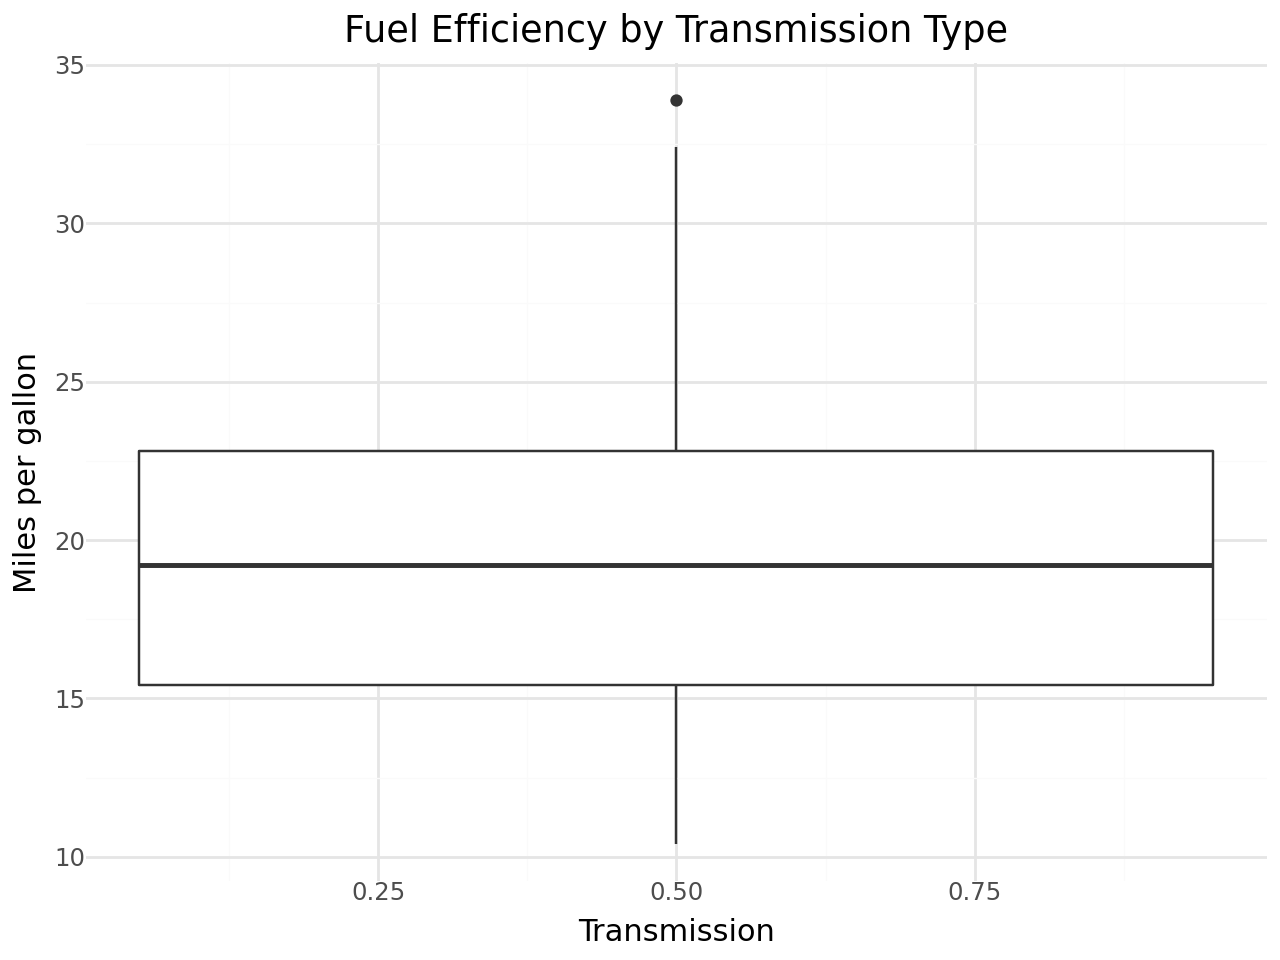

In [5]:
# Enter your code here
# Having "am" as a float made it so that the plots are not two seperate plots, and they are just made into one because the x-axis turns into a number line because it seees the values as continuous numeric data now.
df["am"] = df["am"].astype(float)
from plotnine import ggplot, aes, geom_boxplot, labs, theme_minimal
(
    ggplot(df, aes(x="am", y="mpg"))
    + geom_boxplot()
    + labs(
        x="Transmission",
        y="Miles per gallon",
        title="Fuel Efficiency by Transmission Type"
    )
    + theme_minimal())

3\. Create overlaid histograms of the `hp` variable for the different values of the `cyl` variable.

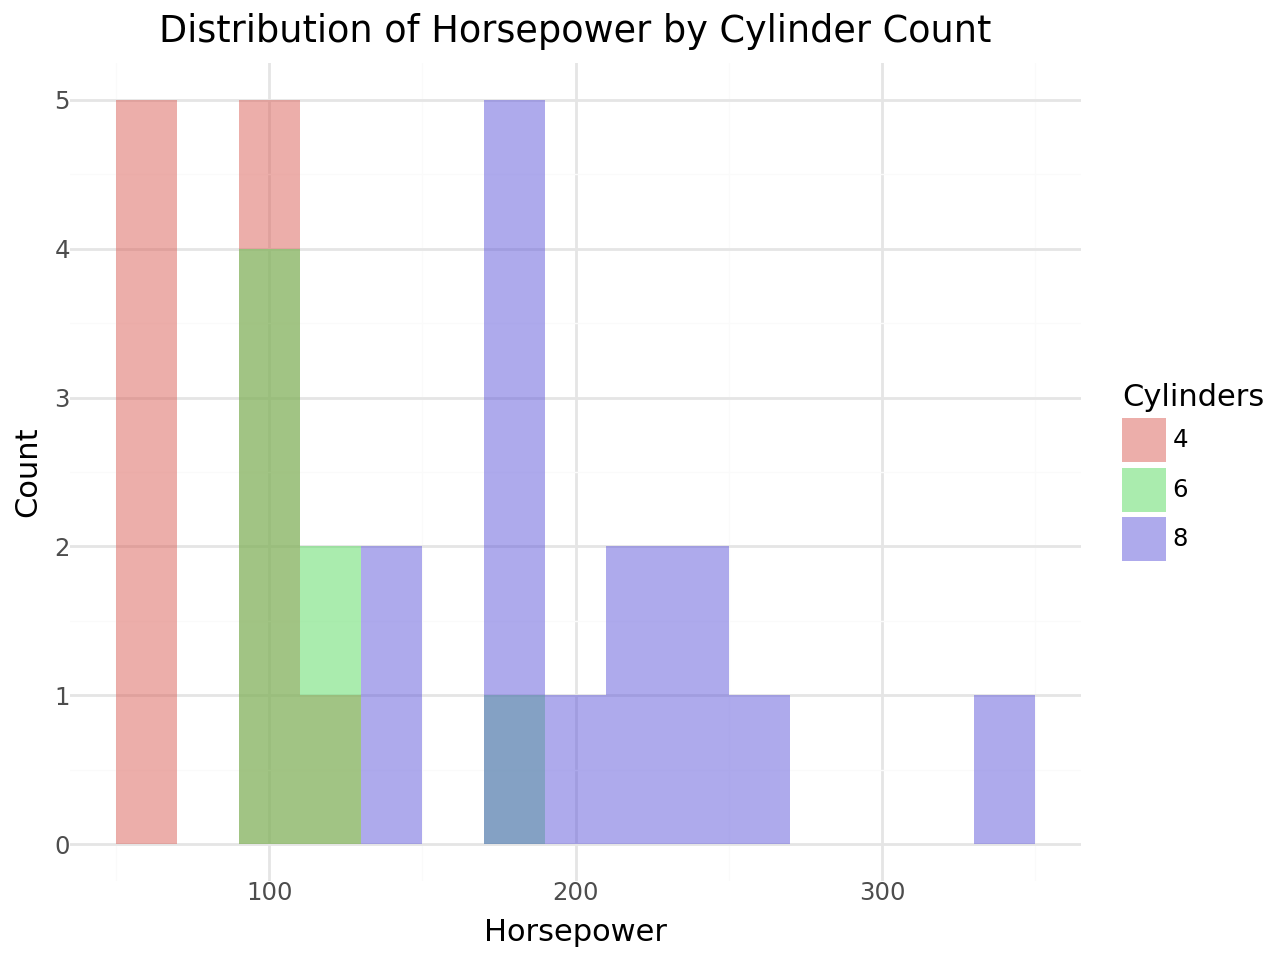

In [6]:
# Enter your code here
from plotnine import ggplot, aes, geom_histogram, labs, theme_minimal

df["cyl"] = df["cyl"].astype("category")

(
    ggplot(df, aes(x="hp", fill="cyl"))
    + geom_histogram(binwidth=20, position="identity", alpha=0.5)
    + labs(
        x="Horsepower",
        y="Count",
        title="Distribution of Horsepower by Cylinder Count",
        fill="Cylinders"
    )
    + theme_minimal()
)

4\. What happens if you convert the `cyl` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

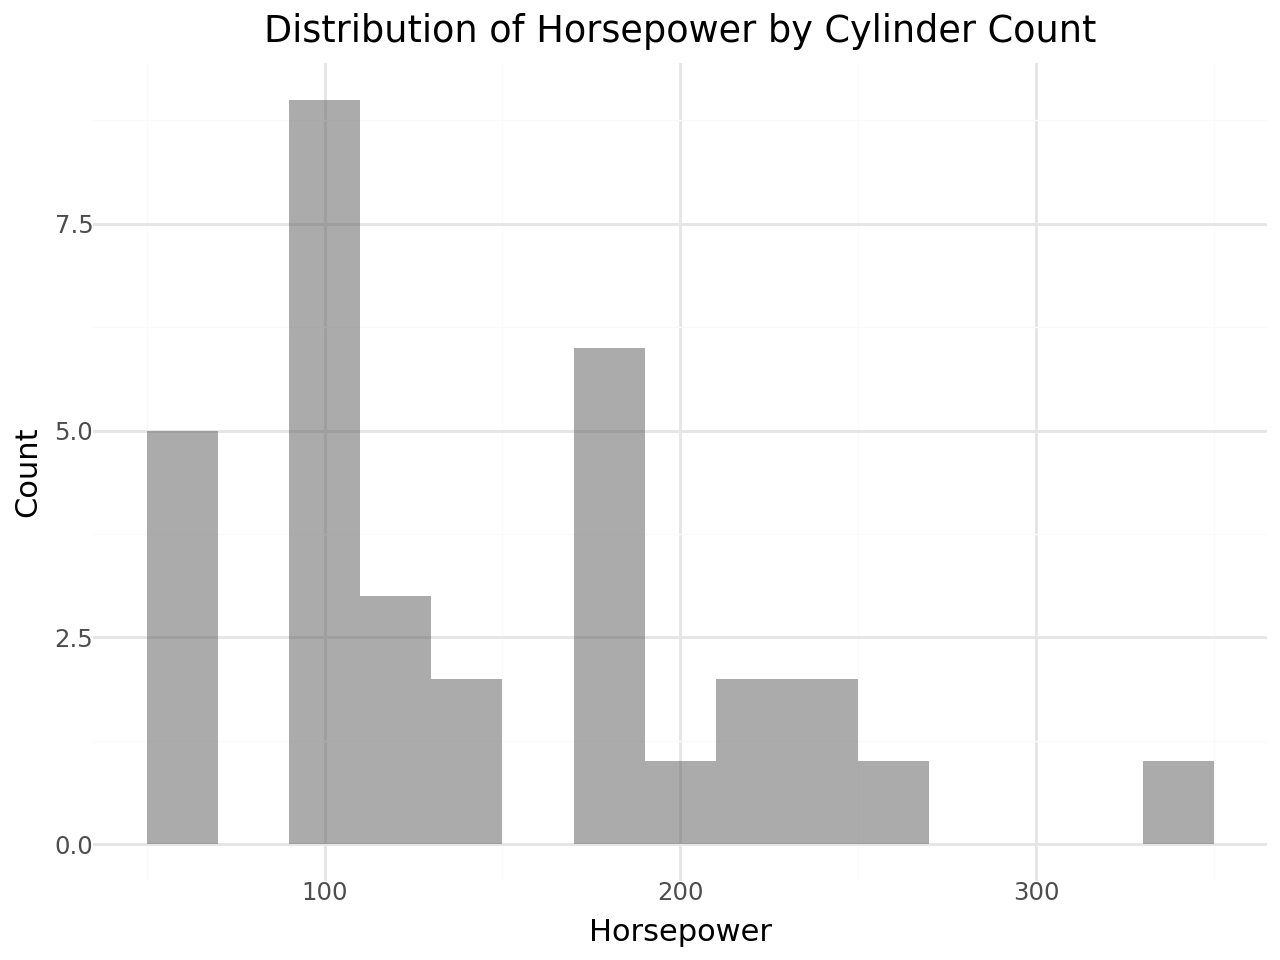

In [7]:
# Enter your code here
# When I convert it to a float it turns all the values gray because now it sees them as continuous numeric variables instead of 3 distinct categories.
df["cyl"] = df["cyl"].astype(float)
from plotnine import ggplot, aes, geom_histogram, labs, theme_minimal


(
    ggplot(df, aes(x="hp", fill="cyl"))
    + geom_histogram(binwidth=20, position="identity", alpha=0.5)
    + labs(
        x="Horsepower",
        y="Count",
        title="Distribution of Horsepower by Cylinder Count",
        fill="Cylinders"
    )
    + theme_minimal()
)

5\. Choose a new `geometry` from the [data-to-viz website](https://www.data-to-viz.com/) or look in the [`plotnine` graph gallery](https://python-graph-gallery.com/plotnine/) for a graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

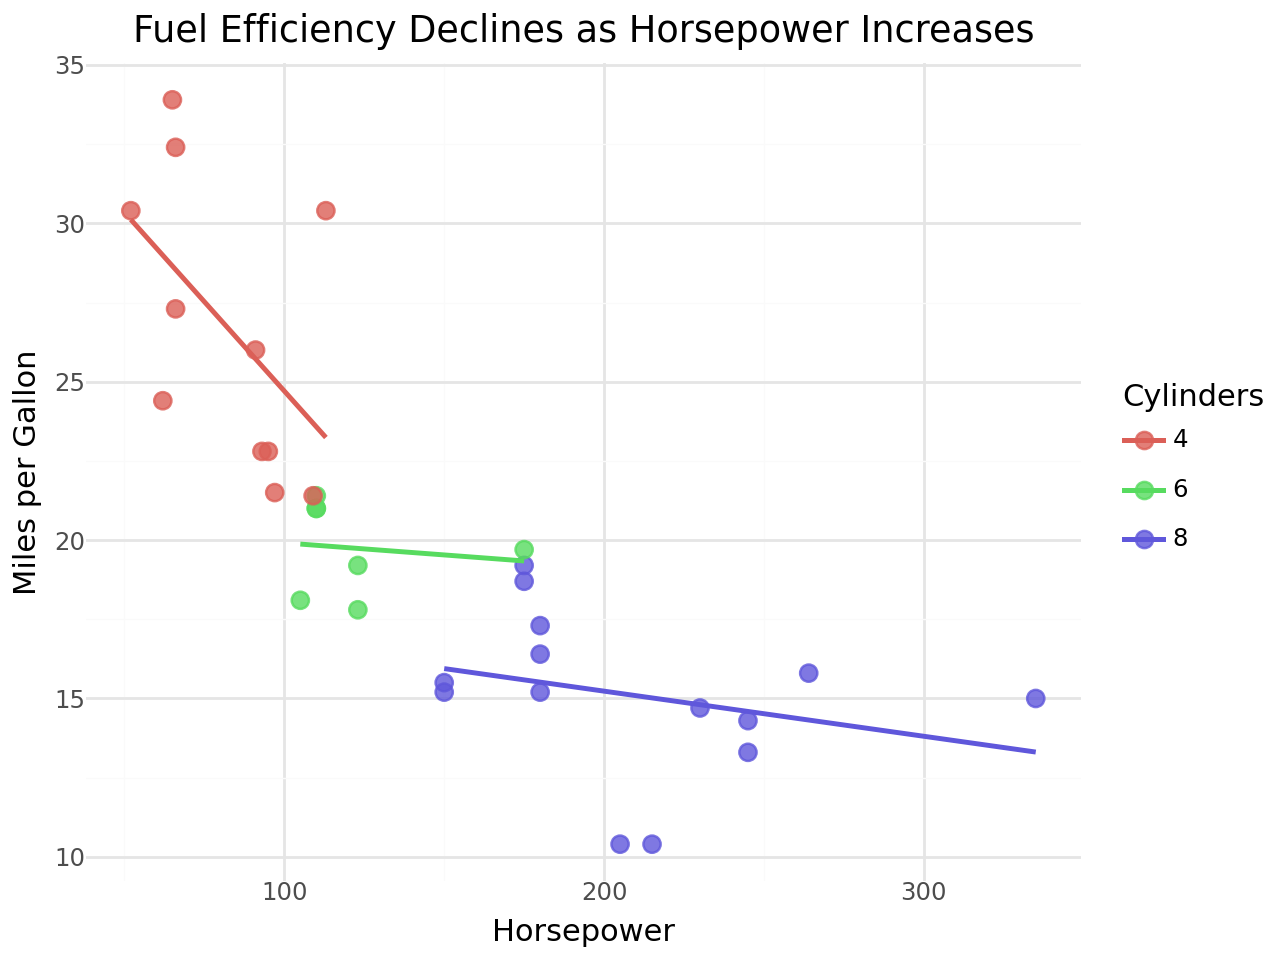

In [8]:
# Enter your code here
from plotnine import (
    ggplot, aes, geom_point, geom_smooth,
    labs, theme_minimal
)

# Treat cylinder count as a categorical grouping variable
df["cyl"] = df["cyl"].astype(int).astype(str)

(
    ggplot(df, aes(x="hp", y="mpg", color="cyl"))
    + geom_point(size=3, alpha=0.8)
    + geom_smooth(method="lm", se=False)
    + labs(
        title="Fuel Efficiency Declines as Horsepower Increases",
        x="Horsepower",
        y="Miles per Gallon",
        color="Cylinders"
    )
    + theme_minimal()
)

6\. Repeat the previous part for another graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

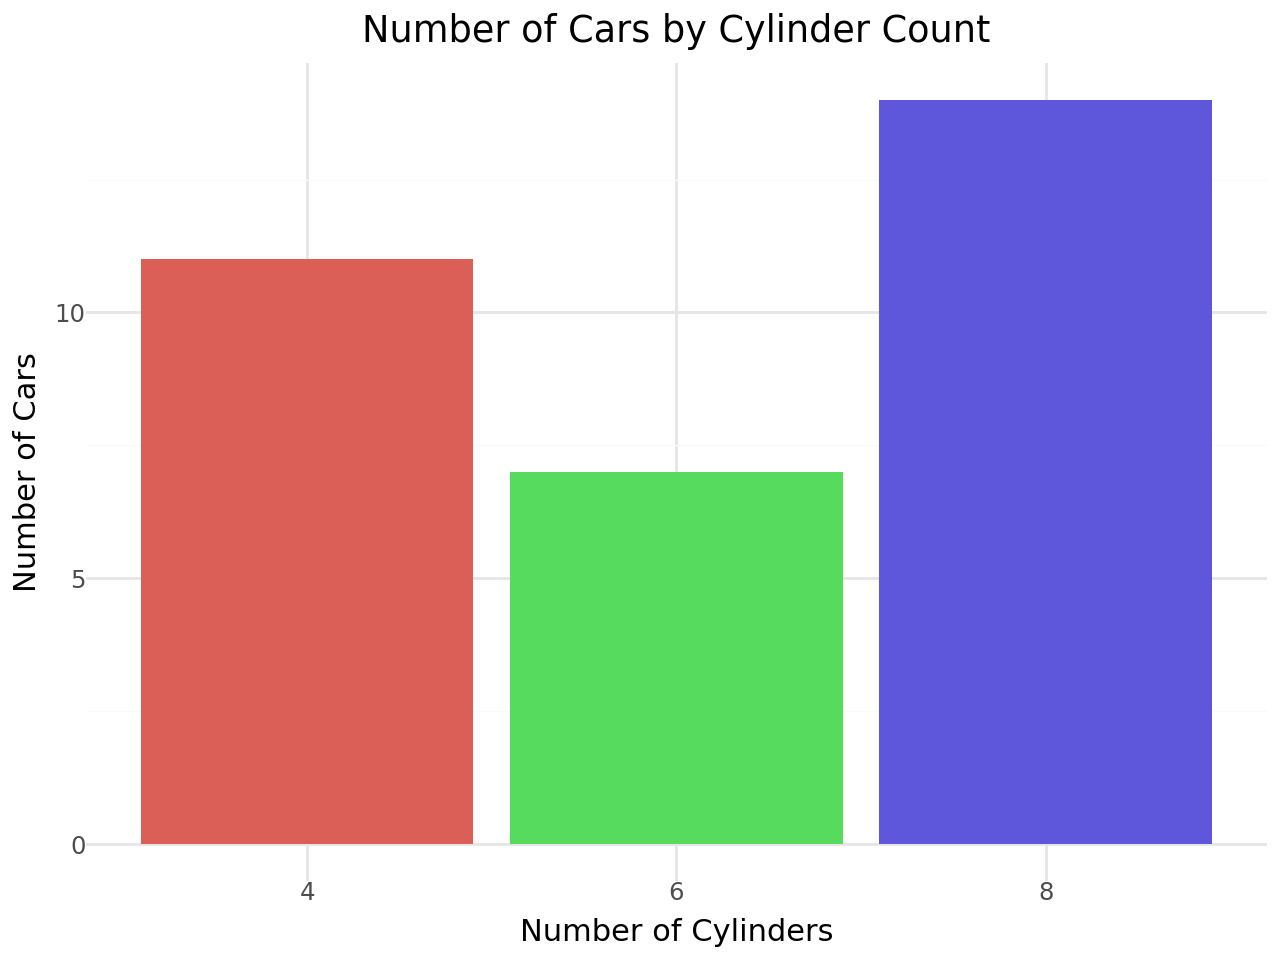

In [9]:
# Enter your code here
from plotnine import (
    ggplot, aes, geom_bar, labs, theme_minimal
)

df["cyl"] = df["cyl"].astype(int).astype(str)

(
    ggplot(df, aes(x="cyl", fill="cyl"))
    + geom_bar(show_legend=False)
    + labs(
        title="Number of Cars by Cylinder Count",
        x="Number of Cylinders",
        y="Number of Cars"
    )
    + theme_minimal()
)

## FEV Data

(You saw this data set in [GSB 518](https://kevin-davisross.quarto.pub/gsb518-notes/hw-09.html#problem-3).) Do non-smokers have better lungs than smokers? One measure of lung function is forced expiratory volume (FEV), the amount of air (in liters) an individual can exhale in the first second of forceful breath. Larger values of FEV are indicative of better functioning lungs. In a study, FEV was measured for a group of 654 subjects, along with whether they smoked and other variables like age (years). [Here is the data.](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv)

[This plot](https://drive.google.com/file/d/1dm7U1cpVpHrbNZrBymOdmtkhMX3U7BwU/view?usp=sharing) was made using `plotly`. Use AI to help reproduce it using `plotnine`. Think in terms of the grammar of graphics and the design of the plot and write prompts like "The x-axis is mapped to Age". It might help to [try the two practice activities in Section 3.6.3 first](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html#try-it-out). (Hint: this is really 3 separate plots. Consider using the `patchworklib` package, which you need to install in Colab space first.)


In [6]:
import pandas as pd
!pip -q install numpy==1.26.4 pandas==2.2.3 plotnine==0.13.6 mizani==0.11.4

from plotnine import(
    ggplot, aes,
    geom_point, geom_smooth, geom_histogram,
    labs, theme_minimal, theme,
    element_blank, coord_flip
)

import io
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def ggplot_to_image(gg_plot, width, height, dpi=150):
    buf = io.BytesIO()
    gg_plot.save(
        buf,
        format="png",
        width=width,
        height=height,
        dpi=dpi,
        verbose=False
    )
    buf.seek(0)
    return Image.open(buf)

# Load the FEV data
fev = pd.read_csv(
    "https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv"
)

# Preprocess the FEV data, using corrected column names based on previous interactions
fev.columns = fev.columns.str.lower()
fev["age_months"] = fev["age (months)"]
fev["smoking_status"] = fev["smoking status"].astype("category")

# Define the three ggplot objects
p1_middle = (
    ggplot(fev, aes(x="age_months", y="fev", color="smoking_status"))
    + geom_point(alpha=0.75, size=2)
    + geom_smooth(method="lm", se=False)
    + labs(
        title="FEV by Age and Smoking Status",
        x="Age (months)",
        y="FEV (liters)",
        color="Smoking status"
    )
    + theme_minimal()
)

p2_top = (
    ggplot(fev, aes(x="age_months", fill="smoking_status"))
    + geom_histogram(
        bins=20,
        position="identity",
        alpha=0.45,
        color="white"
    )
    + theme_minimal()
    + theme(
        axis_title=element_blank(),
        axis_text_x=element_blank(),
        axis_text_y=element_blank(),
        legend_position="none"
    )
)

p3_right = (
    ggplot(fev, aes(x="fev", fill="smoking_status"))
    + geom_histogram(
        bins=20,
        position="identity",
        alpha=0.45,
        color="white"
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        axis_title=element_blank(),
        axis_text_x=element_blank(),
        axis_text_y=element_blank(),
        legend_position="none"
    )
)

# Convert ggplot objects to images
img_top = ggplot_to_image(p2_top, width=6, height=1.5)
img_main = ggplot_to_image(p1_middle, width=6, height=4)
img_right = ggplot_to_image(p3_right, width=1.5, height=4)

fig = plt.figure(figsize=(8, 6))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[6, 1.5],
    height_ratios=[1.5, 4],
    wspace=0,
    hspace=0
)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

ax_top.imshow(img_top)
ax_main.imshow(img_main)
ax_right.imshow(img_right)

ax_top.axis("off")
ax_main.axis("off")
ax_right.axis("off")

plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 83.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
datasets 4.0.0 requires dill<0.3.9,>=0.3.0, but you have dill 0.4.1 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


ModuleNotFoundError: No module named 'numpy.rec'

## Olympic Men's Gymnastics Data

[This file](https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv) contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

1\. Your goal will be to create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. But first...


This data is in "wide format" in that the scores are spread over six columns.

| Floor score | Pommel score | Rings score | Vault score | Pbar score | Hbar score |
|------------:|-------------:|------------:|------------:|-----------:|-----------:|
|        15.0 |         14.5 |        15.2 |        16.1 |       14.6 |       15.0 |


In order to produce some plots (and work with the grammar of graphics more fully), you might need to reformat the data so that it is "long format" with one column for score and a new column for "event".

| Event  | Score |
|--------|------:|
| Floor  |  15.0 |
| Pommel |  14.5 |
| Rings  |  15.2 |
| Vault  |  16.1 |
| Pbar   |  14.6 |
| Hbar   |  15.0 |

1. Create a new data frame with the scores in long format, with columns labeled "Event" and "Score". There are a few ways to do this, so see what you can find!


In [4]:
# YOUR CODE HERE
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")
df_gym
df_gym_long = df_gym.melt(id_vars = ["Gymnast", "NOC", "Round", "Year"],
                          value_vars=["Floor Exercise", "Pommelled Horse", "Rings", "Horse Vault", "Parallel Bars", "Horizontal Bar"],
                          var_name = "event", value_name = "score")


2\. Now create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. Be creative! Share your graph with a classmate and discuss why you designed it the way you did.

In [5]:
# YOUR CODE HERE
from plotnine import *
(
    ggplot(df_gym_long.dropna(),
           aes(x="event", y="score", fill="Round"))
    + geom_boxplot()
    + facet_wrap("Year")
    + coord_flip()
    + labs(
        x="event",
        y="score",
        fill="Round",
        title="Olympic Men's Gymnastics Scores by Event, Year, and Round"
    )
    + theme_bw()
)

ModuleNotFoundError: No module named 'numpy.rec'